
# Lab 8: Monte Carlo Markov Chain (MCMC)

## Modelo de Ising 2D

Como aplicación de la distribución canónica en `Física estadística` tenemos el modelo de **Ising**.

Para el caso de un material paramagnético de átomos de spin $1/2$ y momento magnetico $\mu_0$ en presencia de un campo magnético externo $H$, se ha determinado experimentalmente que la magnetización media depende del campo magnético y la temperatura del material. Consultar: (https://en.wikipedia.org/wiki/Ising_model)

**Exercise**: Considere un sistema compuesto por $N$ átomos no interactuantes en un material 2D, a una temperatura $T$ y en presencia de un campo magnético externo $H$ que está orientado en cierta dirección fija respecto al material:

<img src="https://upload.wikimedia.org/wikipedia/commons/f/fe/2D_ising_model_on_lattice.svg" width="550">

1. Realizar la simulación mediante el uso del método de Metrópolis Monte Carlo para este sistema. En este caso, visitar todos los
posibles spines de la red cristalina del material e intentear inversiones bajo condiciones adecuadas de energía y estabilidad del sistema:

    Algoritmo:
    * *Selecciona* un microestado $x$ inicial de manera aleatoria para todos los espines de la red (spin: +1 arriba y -1 abajo). Esta es la configuración inicial.
    * *Visitar* aleatoriamente un punto de la red y hacer una inversión de su espín... configuración $x'$.
    * *Aceptación*: Comprobar la energia $E$ del sistema. 
            Si la energía disminuye se acepta la nueva configuración $x'$. 
            Si aumenta, se debe generar un número aleatorio entre $[0,1]$. Si este número es mayor que el factor de Boltzman $\mathcal{P}(E,T)=e^{-E/(KT)}$ se rechaza $x'$. De lo contrario se acepta la nueva configuración $x'$.
    * *Repetir* los pasos anteriores.
    * *Finalizar*: Cuando llegue al creterio de finalización se debe terminar.


2. Graficar la Magnetización media del material vs el campo magnetico para tres temperaturas reducidas (H/T) con $T=\{5,15,20\}$ K (Kelvin) y un campo variable $-30\,G < H < +30\,G$ (Gauss), .  Monstrar que la distribución canónica de la magnetización clásica es muy acertada (consultar). 
3. Investigar el resultado analítico para este sistema 2D y comparar con la simulación de MC. ¿Qué tan precisa es la simulación? Explique.

## Solución al Modelo de Ising: Método de Metrópolis Monte Carlo


Dadas las condiciones iniciales de. la red cristalina del material, tenemos que un sistema 2D de N átomos no interactuantes (J=0) con un estado aleatorio donde la alineación de los espines depende exclusivamente del campo $H$, tendremos por lo tanto el siguiente código:



In [1]:
# Librerias:

import numpy as np
import matplotlib.pyplot as plt 

In [8]:
def Mod_Ising(L, H, T, pasos_mc):
    """
    Simulación Monte Carlo de un paramagneto tipo Ising
    mediante el algoritmo de Metropolis.

    Parámetros
    ----------
    L : int
        Tamaño de la red cuadrada (L x L).

    H : float
        Campo magnético externo.

    T : float
        Temperatura del sistema (se asume k_B = 1).

    pasos_mc : int
        Número de intentos Monte Carlo.

    Retorna
    -------
    float
        Magnetización media final del sistema.
    """
    # Configuración inicial aleatoria
    red = np.random.choice([-1, 1], size=(L, L))

    # -------------------------
    # Etapa de equilibración: Su único propósito es dejar que el sistema “olvide” la condición inicial. Para que el promedio Inicial no quede sesgado. Para calcular cantidades 
    #                          Termodinámicas en estados de equilibrio.
    # -------------------------
    pasos_equilibrio = pasos_mc // 3

    for _ in range(pasos_equilibrio):
        # Asignar aleatoriamente los espines iniciales
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)

        s_actual = red[i, j]

        delta_E = 2.0 * H * s_actual

        if delta_E <= 0:
            red[i, j] = -s_actual

        elif np.random.rand() < np.exp(-delta_E / T):
            red[i, j] = -s_actual

    # -------------------------
    # Etapa de medición
    # Una vez alcanzado el equilibrio térmico se
    # continúan realizando actualizaciones Monte Carlo.
    # Después de cada actualización se calcula la magnetización instantánea:
    # M = (1/N) Σ s_i
    # y se almacena para obtener posteriormente un promedio estadístico.
    # -------------------------
    magnetizaciones = []

    for _ in range(pasos_mc - pasos_equilibrio):

        i = np.random.randint(0, L)
        j = np.random.randint(0, L)

        s_actual = red[i, j]

        delta_E = 2.0 * H * s_actual

        if delta_E <= 0:
            red[i, j] = -s_actual

        elif np.random.rand() < np.exp(-delta_E / T):
            red[i, j] = -s_actual

        magnetizaciones.append(np.mean(red))

    return np.mean(magnetizaciones)

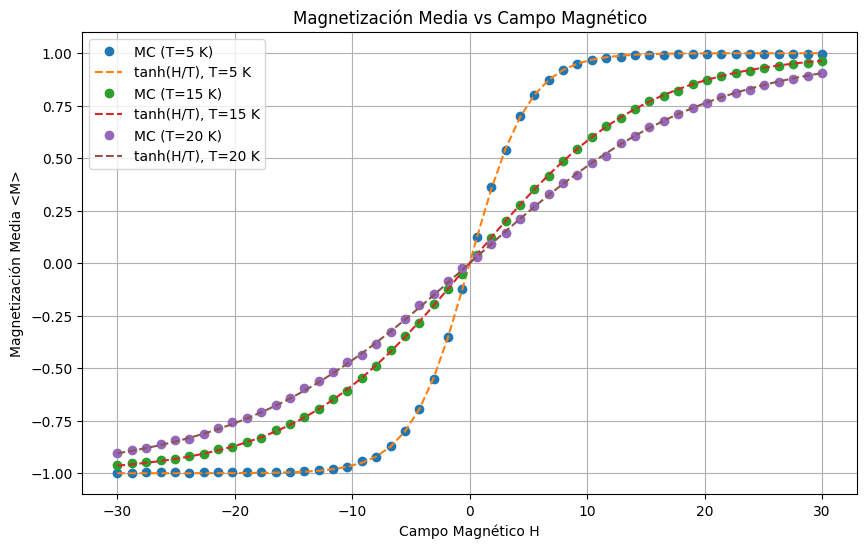

In [ ]:
# Condiciones iniciales:
L = 30                  # Malla de 30x30 (N=900 spines) 
pasos_mc = 10000
campos_H = np.linspace(-30, 30, 50)  #Campo magnético externo
temperaturas = [5, 15, 20]


# Ploteo de figura:
plt.figure(figsize=(10, 6))
for T in temperaturas:
    mag_simulada = []
    for H in campos_H:

        # Promedio de varias corridas
        m = np.mean([
            Mod_Ising(L, H, T, pasos_mc)
            for _ in range(5)
        ])

        mag_simulada.append(m)

    plt.plot(
        campos_H,
        mag_simulada,
        'o',
        label=f"MC (T={T} K)"
    )

    mag_teorica = np.tanh(campos_H / T)

    plt.plot(
        campos_H,
        mag_teorica,
        '--',
        label=f"tanh(H/T), T={T} K"
    )

plt.title("Magnetización Media vs Campo Magnético")
plt.xlabel("Campo Magnético H")
plt.ylabel("Magnetización Media <M>")
plt.grid(True)
plt.legend()
plt.show()